# Abstract

This project focuses on predicting the sales of products across various BigMart outlets using machine learning techniques. The dataset contains information about product attributes such as weight, price, and visibility, along with outlet characteristics like size, location, and type.
The main objective is to build a model that can accurately estimate Item_Outlet_Sales based on these features. Data preprocessing techniques such as handling missing values and encoding categorical variables are applied, followed by exploratory data analysis to understand patterns and relationships.
Multiple machine learning models are implemented and evaluated to identify the best-performing model. The results help in understanding the key factors affecting sales and can assist businesses in making better decisions related to inventory management and sales optimization.

# Problem Statement

BigMart is a retail company with multiple outlets across different locations. The company wants to understand the factors affecting sales of products in various stores.
The objective of this project is to build a predictive model that estimates the Item_Outlet_Sales for each product at a particular outlet based on product characteristics and store details.
The dataset includes information such as product type, price, visibility, outlet size, location, and type of store. Using this data, the goal is to analyze patterns and develop a machine learning model that can accurately predict future sales

# Objective

The objective of this project is to develop a machine learning model that can accurately predict Item_Outlet_Sales for products across different outlets using available features such as product attributes and store characteristics

# Dataset Description

The dataset used in this project is the BigMart Sales dataset, which contains information about products and the outlets where they are sold. It is divided into two parts: a training dataset and a testing dataset.
The training dataset includes both input features and the target variable Item_Outlet_Sales.
The testing dataset contains only input features and is used to make predictions.

In [1]:
# impoting all libraries

#Basic libraries
import numpy as np
import pandas as pd
import seaborn as sb
import warnings
import matplotlib.pyplot as plt

#for skewness
from scipy.stats import skew

#for encoding
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

#for train and test
from sklearn.model_selection import train_test_split

#Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
# importing the train and test dataset
bigmart_dataset = pd.read_csv('Train.csv')
bigmart_dataset_test = pd.read_csv('Test.csv')

# For Train.csv File

In [3]:
bigmart_dataset

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [4]:
bigmart_dataset.shape

(8523, 12)

In [5]:
bigmart_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
bigmart_dataset.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Obsevation

1. Item_Weight,Outlet_Size,Outlet_Location_Type and Outlet_Type are categorical type and the remaining columns are integer or float type

2. Item_Weight and Outlet_Size have null values

### Handling Null values

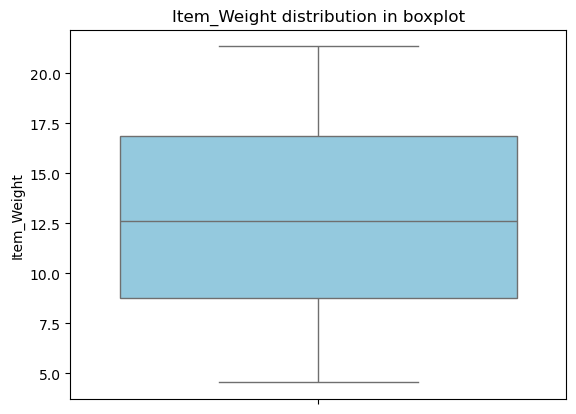

In [7]:
# Item_Weight

sb.boxplot(bigmart_dataset['Item_Weight'],color= 'skyblue') 
plt.title('Item_Weight distribution in boxplot')
plt.show()

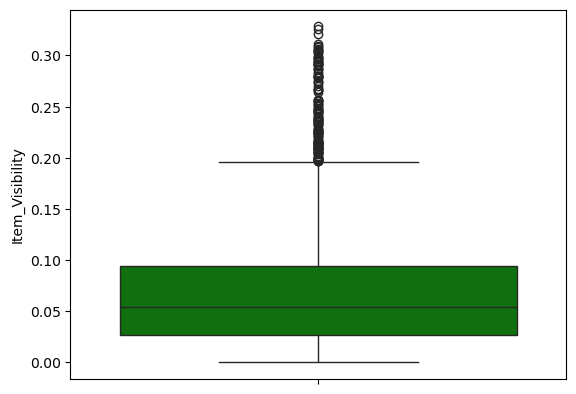

In [8]:
sb.boxplot(y=bigmart_dataset['Item_Visibility'], color = 'g')
plt.show()

# Result-
1. Item_Weight column has symmetrical distribution....so we can use mean to fill NaN values
2. Outlet_Size column is categorical type so we will use mode to fill NaN values

In [9]:
warnings.filterwarnings('ignore')

In [10]:
# Item_Weight
bigmart_dataset['Item_Weight'].fillna(np.mean(bigmart_dataset['Item_Weight']), inplace= True)

#Outlet_Size
bigmart_dataset['Outlet_Size'].fillna(bigmart_dataset['Outlet_Size'].mode()[0],inplace= True)

In [11]:
bigmart_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# Handling Outliers

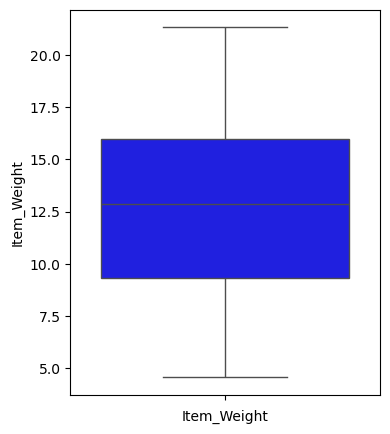

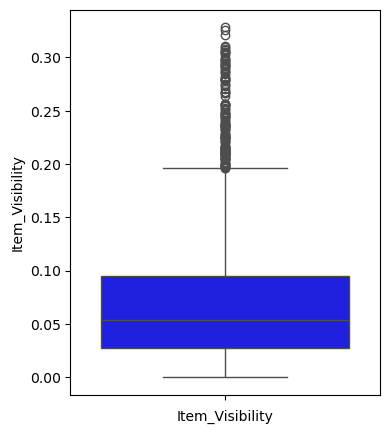

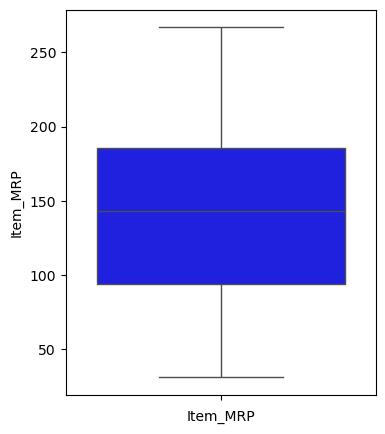

In [12]:
int_col= ['Item_Weight', 'Item_Visibility', 'Item_MRP',]
for a in int_col:
    plt.figure(figsize= (4,5))
    sb.boxplot(y= bigmart_dataset[a], color= 'b')
    plt.xlabel(a)
    plt.show()

In [13]:
bigmart_dataset['Item_Visibility'].describe()

count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64

## Observation from Boxplot

Item_MRP,Item_Weight have no outliers

Item_Visibility has outliers but we wont remove them...because it is possible in real life cases.

In [14]:
bigmart_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# EDA(Exploratory Data Analysis)

In [15]:
for b in bigmart_dataset.columns:
    if bigmart_dataset[b].dtype== object:
        print('*************************')
        print(b)
        print(bigmart_dataset[b].unique())

*************************
Item_Identifier
['FDA15' 'DRC01' 'FDN15' ... 'NCF55' 'NCW30' 'NCW05']
*************************
Item_Fat_Content
['Low Fat' 'Regular' 'low fat' 'LF' 'reg']
*************************
Item_Type
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']
*************************
Outlet_Identifier
['OUT049' 'OUT018' 'OUT010' 'OUT013' 'OUT027' 'OUT045' 'OUT017' 'OUT046'
 'OUT035' 'OUT019']
*************************
Outlet_Size
['Medium' 'High' 'Small']
*************************
Outlet_Location_Type
['Tier 1' 'Tier 3' 'Tier 2']
*************************
Outlet_Type
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


# Observation-

Item_Fat_Contain haves duplicate categorical values 

Item_Identifier contains meaningful patterns in its pefix(FD, DR,NC), which represents different product categories like Food, Drinks and Non-Consumable

In [16]:
# Removing duplicate values

bigmart_dataset['Item_Fat_Content'].replace({'low fat':'Low Fat', 'LF':'Low Fat', 'reg':'Regular'}, inplace= True)
bigmart_dataset['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular'], dtype=object)

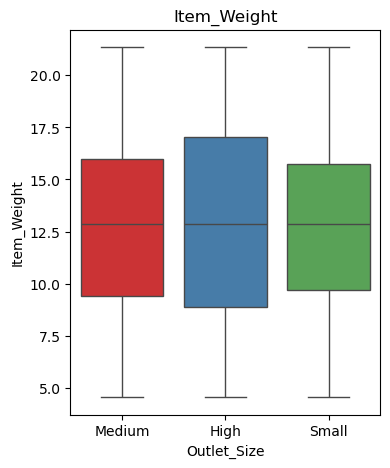

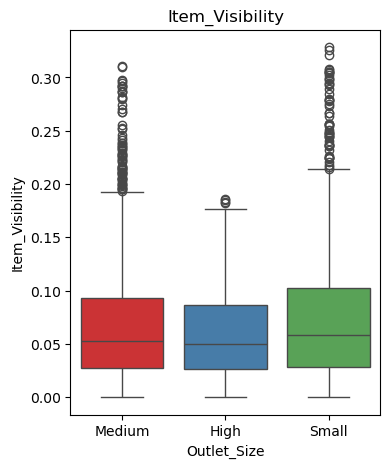

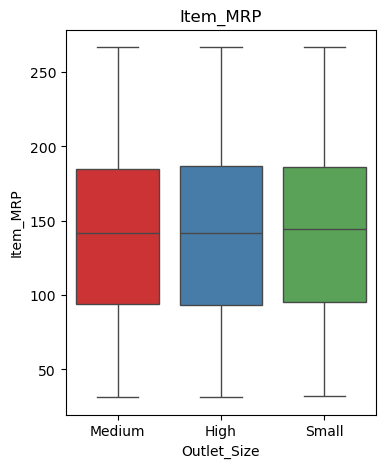

In [17]:
#analyzing the data with respect to Outlet_Size

cols= ['Item_Weight','Item_Visibility','Item_MRP']
for x in cols:

    plt.figure(figsize=(4,5))
    sb.boxplot(x= bigmart_dataset['Outlet_Size'], y= bigmart_dataset[x],palette= 'Set1')
    plt.title(x)
    plt.show()

# Observation

1. IQR of High Outlet(size) has spread more than other outlets.
2. In Item_Visibility boxplot, we can conclude that small and medium outlet(shops) promotes many poducts whereas, High outlet promotes only few products
3. MRP is almost same in all outlets but 'high' outlet MRP is slightly more than other

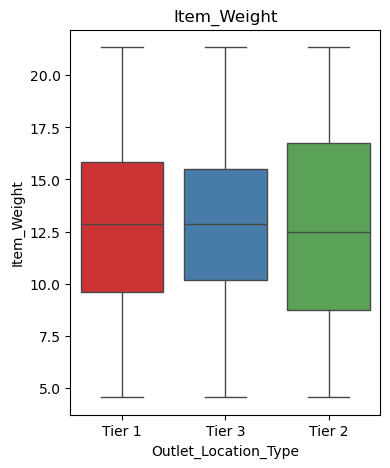

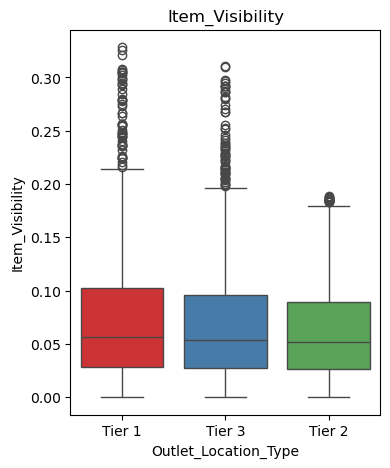

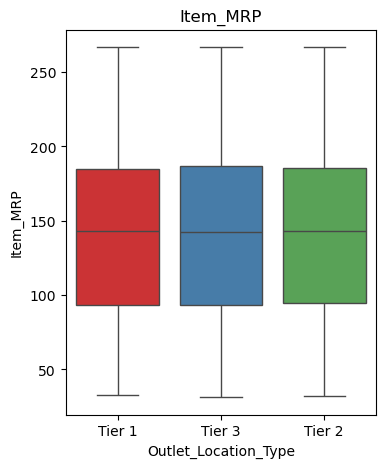

In [18]:
#analyzing the data with respect to location type

for a in cols:
    plt.figure(figsize= (4,5))
    sb.boxplot(y= bigmart_dataset[a], x= bigmart_dataset['Outlet_Location_Type'], palette= 'Set1')
    plt.title(a)
    plt.show()

# Observation

1. IQR of Tier2 > IQR of Tier1> IQR of Tier3... which means 

2. All 3 tiers have outliers. Tier1 location promotes product more than other Tiers

3. All Tiers sell products at almost same MRP

In [19]:
for i in bigmart_dataset.columns:
    if bigmart_dataset[i].dtype!= object:
        print(i)
        print(bigmart_dataset[i].value_counts())
        print('*******************************')

Item_Weight
Item_Weight
12.857645    1463
12.150000      86
17.600000      82
13.650000      77
11.800000      76
             ... 
5.210000        2
9.420000        1
7.685000        1
5.400000        1
6.520000        1
Name: count, Length: 416, dtype: int64
*******************************
Item_Visibility
Item_Visibility
0.000000    526
0.076975      3
0.107274      2
0.074613      2
0.045166      2
           ... 
0.056783      1
0.046982      1
0.035186      1
0.145221      1
0.016827      1
Name: count, Length: 7880, dtype: int64
*******************************
Item_MRP
Item_MRP
172.0422    7
196.5084    6
196.5768    6
109.5228    6
188.1872    6
           ..
213.9902    1
231.5984    1
57.5904     1
214.5218    1
75.4670     1
Name: count, Length: 5938, dtype: int64
*******************************
Outlet_Establishment_Year
Outlet_Establishment_Year
1985    1463
1987     932
1999     930
1997     930
2004     930
2002     929
2009     928
2007     926
1998     555
Name: count, d

## Observation

Item visibility cannot be zero (if its zero it means that its invisible to customers)

In Outlet_Establishment_Year,model cannot understand how old a store is because of big values so we will subtract it with current year

In [20]:
bigmart_dataset['Item_Visibility'].replace(0, bigmart_dataset['Item_Visibility'].median(), inplace = True)

In [21]:
bigmart_dataset['Outlet_Establishment_Year'] = 2026 - bigmart_dataset['Outlet_Establishment_Year']

# Encoding

In [22]:
#LabelEncoder
#Item_Fat_Content
le = LabelEncoder()
bigmart_dataset['Item_Fat_Content'] = le.fit_transform(bigmart_dataset['Item_Fat_Content'])

In [23]:
# Outlet_Location_Type
bigmart_dataset['Outlet_Location_Type'] = le.fit_transform(bigmart_dataset['Outlet_Location_Type']) 
#Tier 1-0
#Tier 2 - 1
#Tier 3- 2

In [24]:
#Outlet_Size
bigmart_dataset['Outlet_Size'] = le.fit_transform(bigmart_dataset['Outlet_Size'])

In [25]:
# Item_Identifier 
bigmart_dataset['Item_Identifier'] = le.fit_transform(bigmart_dataset['Item_Identifier'])

In [26]:
#OneHotEncoder

#Item_Type
enc_type= pd.get_dummies(bigmart_dataset['Item_Type'], dtype =int)

In [27]:
#Outlet_Type
enc_outlet_type = pd.get_dummies(bigmart_dataset['Outlet_Type'], dtype= int)

In [28]:
bigmart_dataset = pd.concat([bigmart_dataset,enc_type,enc_outlet_type], axis=1)
bigmart_dataset= bigmart_dataset.drop(['Frozen Foods','Grocery Store','Outlet_Type'], axis=1)

In [29]:
bigmart_dataset.shape

(8523, 29)

In [30]:
for x in bigmart_dataset.columns:
    if bigmart_dataset[x].dtype==object:
        print(x)

Item_Type
Outlet_Identifier


## Skewness

In [31]:
bigmart_dataset.skew(numeric_only = True)

Item_Identifier              -0.008877
Item_Weight                   0.090561
Item_Fat_Content              0.616705
Item_Visibility               1.318943
Item_MRP                      0.127202
Outlet_Establishment_Year     0.396641
Outlet_Size                  -0.087072
Outlet_Location_Type         -0.209093
Item_Outlet_Sales             1.177531
Baking Goods                  3.199792
Breads                        5.567533
Breakfast                     8.632562
Canned                        3.196644
Dairy                         3.096356
Fruits and Vegetables         2.021988
Hard Drinks                   6.071724
Health and Hygiene            3.668801
Household                     2.547106
Meat                          4.136741
Others                        6.889767
Seafood                      11.411629
Snack Foods                   2.065882
Soft Drinks                   4.026612
Starchy Foods                 7.390855
Supermarket Type1            -0.649203
Supermarket Type2        

In [32]:
# Applying skewness on Item_Visibility and Item_Outlet_Sales 
bigmart_dataset['Item_Visibility'] = np.sqrt(bigmart_dataset['Item_Visibility'])  #sqrt is used for moderate skewness
bigmart_dataset['Item_Outlet_Sales'] = np.log1p(bigmart_dataset['Item_Outlet_Sales']) #log is used for columns which are highly skewed

# Separating dependent and independent columns 

In [33]:
# Spliting the data

x= bigmart_dataset.drop(['Item_Outlet_Sales','Item_Type','Outlet_Identifier','Item_Identifier'], axis= 1)
y= bigmart_dataset['Item_Outlet_Sales']

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.20, random_state= 42)

In [34]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6818, 25)
(1705, 25)
(6818,)
(1705,)


# Model Training

Item_Outlet_Sales has continuous values, so we will use regression models

### 1. Linear Regression

In [35]:
lr= LinearRegression()

In [36]:
lr.fit(x_train, y_train)

LinearRegression()

In [37]:
y_pred = lr.predict(x_test)

In [38]:
r2_Score = r2_score(y_test, y_pred)

In [39]:
r2_Score*100

72.93726680689323

In [40]:
mse = mean_squared_error(y_test,y_pred)

In [41]:
mse*100

28.45224470317588

### 2.RandomForestRegressor

In [42]:
rf = RandomForestRegressor()

In [43]:
rf.fit(x_train,y_train)

RandomForestRegressor()

In [44]:
y_pred_rf = rf.predict(x_test)

In [45]:
r2_score_rf = r2_score(y_test,y_pred_rf)
r2_score_rf*100

71.44083830422845

In [46]:
mse_rf = mean_squared_error(y_test,y_pred_rf)
mse_rf*100

30.025505971164534

# Result

LinearRegression Model gives 73% accuracy

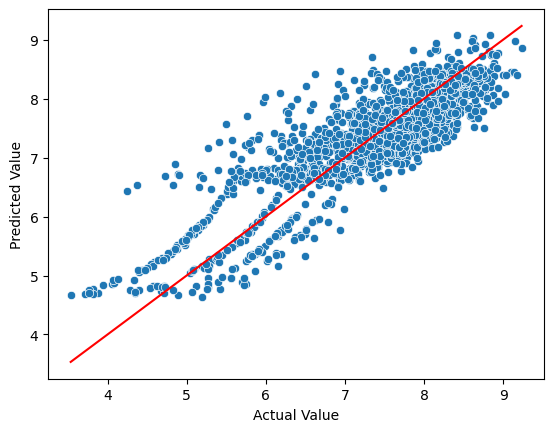

In [47]:
# Plotting scatterplot for actual and predicted value

sb.scatterplot(x= y_test, y= y_pred, palette = 'Set3',markers= '*')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color = 'red')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.show()

* The scatter plot of actual vs predicted values shows that most data points are closely aligned along the diagonal line, indicating good model performance. Some deviation from the line suggests minor prediction errors, which is expected in real-world data 

# For Test.csv file

In [48]:
bigmart_dataset_test

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3
...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1
5677,FDD47,7.600,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2
5678,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,NaN,Tier 2,Supermarket Type1
5679,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,2007,NaN,Tier 2,Supermarket Type1


In [49]:
bigmart_dataset_test.isnull().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

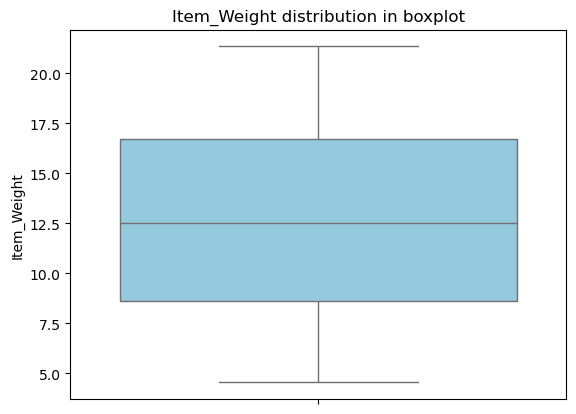

In [50]:
# Item_Weight

sb.boxplot(bigmart_dataset_test['Item_Weight'],color= 'skyblue') 
plt.title('Item_Weight distribution in boxplot')
plt.show()

In [51]:
# Item_Weight
bigmart_dataset_test['Item_Weight'].fillna(np.mean(bigmart_dataset_test['Item_Weight']), inplace= True)

#Outlet_Size
bigmart_dataset_test['Outlet_Size'].fillna(bigmart_dataset_test['Outlet_Size'].mode()[0],inplace= True)

In [52]:
bigmart_dataset_test['Item_Fat_Content'].replace({'low fat':'Low Fat', 'LF':'Low Fat', 'reg':'Regular'}, inplace= True)
bigmart_dataset_test['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular'], dtype=object)

In [53]:
bigmart_dataset_test['Item_Visibility'].replace(0, bigmart_dataset_test['Item_Visibility'].median(), inplace = True)

In [54]:
bigmart_dataset_test['Outlet_Establishment_Year'] = 2026 - bigmart_dataset_test['Outlet_Establishment_Year']

# Encoding

In [55]:
#LabelEncoder
#Item_Fat_Content
le = LabelEncoder()
bigmart_dataset_test['Item_Fat_Content'] = le.fit_transform(bigmart_dataset_test['Item_Fat_Content'])

In [56]:
# Outlet_Location_Type
bigmart_dataset_test['Outlet_Location_Type'] = le.fit_transform(bigmart_dataset_test['Outlet_Location_Type']) 


In [57]:
bigmart_dataset_test['Outlet_Size'].unique()

array(['Medium', 'Small', 'High'], dtype=object)

In [58]:
bigmart_dataset_test['Outlet_Size']= bigmart_dataset_test['Outlet_Size'].astype(str)
bigmart_dataset_test['Outlet_Size'].replace('1', bigmart_dataset_test['Outlet_Size'].mode()[0],inplace = True)

In [59]:
#Outlet_Size
bigmart_dataset_test['Outlet_Size'] = le.fit_transform(bigmart_dataset_test['Outlet_Size'])

In [60]:
# Item_Identifier 
bigmart_dataset_test['Item_Identifier'] = le.fit_transform(bigmart_dataset_test['Item_Identifier'])

In [61]:
#OneHotEncoder

#Item_Type
enc_type= pd.get_dummies(bigmart_dataset_test['Item_Type'], dtype =int)
#Outlet_Type
enc_outlet_type = pd.get_dummies(bigmart_dataset_test['Outlet_Type'], dtype= int)


bigmart_dataset_test = pd.concat([bigmart_dataset_test,enc_type,enc_outlet_type], axis=1)
bigmart_dataset_test= bigmart_dataset_test.drop(['Frozen Foods','Grocery Store','Outlet_Type'], axis=1)

In [62]:
# Applying skewness on Item_Visibility 
bigmart_dataset_test['Item_Visibility'] = np.sqrt(bigmart_dataset_test['Item_Visibility'])  #sqrt is used for moderate skewness

In [63]:
test_data_x= bigmart_dataset_test.drop(['Item_Type','Outlet_Identifier','Item_Identifier'], axis= 1)

In [65]:
bigmart_dataset_test.shape

(5681, 28)

In [80]:
test_data_x = test_data_x.reindex(columns= x_train.columns, fill_value=0) # reindex() 

In [81]:
test_data_x.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy',
       'Fruits and Vegetables', 'Hard Drinks', 'Health and Hygiene',
       'Household', 'Meat', 'Others', 'Seafood', 'Snack Foods', 'Soft Drinks',
       'Starchy Foods', 'Supermarket Type1', 'Supermarket Type2',
       'Supermarket Type3'],
      dtype='object')

In [82]:
x_train.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy',
       'Fruits and Vegetables', 'Hard Drinks', 'Health and Hygiene',
       'Household', 'Meat', 'Others', 'Seafood', 'Snack Foods', 'Soft Drinks',
       'Starchy Foods', 'Supermarket Type1', 'Supermarket Type2',
       'Supermarket Type3'],
      dtype='object')

In [87]:
prediction = lr.predict(test_data_x)
predictions= np.expm1(prediction) # reversing the log transformation

In [86]:
print(predictions)

[1387.37122826 1122.06724508  603.17594762 ... 1583.26371257 3482.72750937
 1137.24626779]
